# 05 · NetKet 中的自回归模型：用现成的轮子跑 VMC

**前置课程**：01 链式法则与自回归分解 → 02 MADE：掩码自回归网络 → 03 训练自回归分布 → 04 自回归量子态与 VMC

前四课我们**徒手**实现了自回归采样与 VMC。本课改用 NetKet 提供的现成组件，在临界横场 Ising 链上做一次"工程实战"。你将学到：

1. **如何 introspect 一个库**：用 `dir()` / `inspect.signature` / docstring 确认 API 真实存在，而不是照抄过时教程；
2. NetKet 3.21 里**真实存在**的自回归模型（`ARNNDense` 等，注意：`nk.models.MADE` 在这个版本**已经不存在**）；
3. 自回归模型为什么要配 **`ARDirectSampler`**，它与默认 `MetropolisSampler` 的本质区别；
4. 一个在本环境（netket 3.21 + jax 0.9.2）下**实测可用**的 SR 配置。

> ⏱ 本 notebook 完整运行约 **3–4 分钟**（其中训练 300 步约 2.5 分钟）。

## 0 · 环境检查

本课依赖的 API 行为与版本强相关（尤其是 SR 的 QGT 实现），所以第一步永远是确认版本。

In [1]:
import sys, inspect
import numpy as np
import jax
import netket as nk

print("Python :", sys.version.split()[0])
print("netket :", nk.__version__)
print("jax    :", jax.__version__)

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: With many Markov Chains (e.g GPUs), n_discard_per_chain>5 is often inefficient.

Python : 3.11.15
netket : 3.21.0
jax    : 0.9.2


## 1 · Introspect：先侦察，再动手

NetKet 的模型在 `nk.models` 命名空间里。教程圈流传的写法常是 `nk.models.MADE`——但库在演进，**3.21 里 MADE 已经被移除**，统一更名为 ARNN（Autoregressive Neural Network）系列。动手前先做一次侦察：

In [2]:
# 侦察 1：nk.models 里有哪些自回归模型？
ar_names = [n for n in dir(nk.models) if "ARNN" in n or "MADE" in n]
print("自回归相关模型：", ar_names)
print()
print("本版本是否存在 nk.models.MADE :", hasattr(nk.models, "MADE"))

自回归相关模型： ['ARNNConv1D', 'ARNNConv2D', 'ARNNDense', 'ARNNSequential', 'AbstractARNN', 'FastARNNConv1D', 'FastARNNConv2D', 'FastARNNDense', 'FastARNNSequential']

本版本是否存在 nk.models.MADE : False


In [3]:
# 侦察 2：看构造函数签名（决定我们能传什么参数）
print("ARNNDense        :", inspect.signature(nk.models.ARNNDense.__init__))
print()
print("docstring        :", nk.models.ARNNDense.__doc__.strip())

ARNNDense        : (self, hilbert: netket.hilbert.homogeneous.HomogeneousHilbert, layers: int, features: tuple[int, ...] | int, activation: collections.abc.Callable[[typing.Union[numpy.ndarray, jax.jaxlib._jax.Array]], typing.Union[numpy.ndarray, jax.jaxlib._jax.Array]] = <hashable partial selu with args=(<PjitFunction of <function selu at 0x122ba45e0>>,) and kwargs={}, hash=250631136133742653>, use_bias: bool = True, param_dtype: Union[NoneType, str, type[Any], numpy.dtype, netket.utils.types._SupportsDType] = <class 'jax.numpy.float64'>, precision: Any = None, kernel_init: collections.abc.Callable[[typing.Any, collections.abc.Sequence[int], typing.Union[NoneType, str, type[typing.Any], numpy.dtype, netket.utils.types._SupportsDType]], jax.jaxlib._jax.Array] = <function variance_scaling.<locals>.init at 0x13bc0f6a0>, bias_init: collections.abc.Callable[[typing.Any, collections.abc.Sequence[int], typing.Union[NoneType, str, type[typing.Any], numpy.dtype, netket.utils.types._SupportsDTy

In [4]:
# 侦察 3：配套的直接采样器是否存在？
print("nk.sampler.ARDirectSampler 存在 :", hasattr(nk.sampler, "ARDirectSampler"))
print()
print(nk.sampler.ARDirectSampler.__doc__.strip()[:500])

nk.sampler.ARDirectSampler 存在 : True

Direct sampler for autoregressive neural networks.

    This sampler only works with Flax models.
    This flax model must expose a specific method, `model.conditional`, which given
    a batch of samples and an index `i∈[0,self.hilbert.size]` must return the vector
    of partial probabilities at index `i` for the various (partial) samples provided.

    In short, if your model can be sampled according to a probability
    $ p(x) = p_1(x_1)p_2(x_2|x_1)\dots p_N(x_N|x_{N-1}\dots x_1) $ then
    


**侦察结论**

| 侦察项 | 结果 |
|---|---|
| `nk.models.MADE` | ❌ 不存在（3.21 已移除，早期版本才有） |
| `nk.models.ARNNDense` | ✅ 掩码全连接自回归网络——MADE 的继任者，本课主角 |
| `nk.models.FastARNNDense` / `FastARNNConv1D` 等 | ✅ 存在，"快"版自回归网络（缓存增量更新）。但注意：其 docstring 自述 **不支持 JIT**，在 jax 0.9.2 下实测直接报错 `Slice entries must be static integers`，本课不使用 |
| `nk.sampler.ARDirectSampler` | ✅ 直接采样器，要求模型暴露 `conditional` 方法 |

`ARNNDense(hilbert, layers, features)`：对 $N$ 个自旋做**逐位自回归**的全连接网络——输出位 $x_i$ 的条件概率 $P(x_i \mid x_{<i})$ 只依赖掩码允许的前缀位，与 02 课手写的 MADE 是同一个思想。

## 2 · 问题设定：临界横场 Ising 链

取 $N=8$ 的周期链，哈密顿量用 `nk.operator.Ising`（NetKet 约定 $H = -J\sum_{\langle i,j\rangle}\sigma_i^z\sigma_j^z - h\sum_i \sigma_i^x$）：

- $J=-1$（即 $+1\,\sigma^z\sigma^z$ 的反铁磁耦合；$N$ 为偶数且周期边界时，经子格旋转变换与铁磁情形完全等价），
- $h=1$：落在 $h=|J|$ 的**量子临界点**上——波函数各处涨落，是检验变分模型的标准考题。

参照能量用**精确对角化**（`nk.exact.full_ed`，$2^8=256$ 维，秒级）算出。注意它的真实签名是 `full_ed(operator)`——网上很多资料写 `full_ed(hi, H)`，在本版本会直接报错。

In [5]:
N = 8                      # 链长（可用 6 进一步提速）
hi = nk.hilbert.Spin(s=1 / 2, N=N)
g = nk.graph.Chain(length=N, pbc=True)
H = nk.operator.Ising(hi, graph=g, h=1.0, J=-1.0)

E0_arr = nk.exact.full_ed(H)          # 注意：只传算符，不是 (hilbert, H)
E0 = float(E0_arr[0])
print(f"ED 精确基态能量 E0 = {E0:.6f}  （希尔伯特空间维度 {hi.n_states}）")

ED 精确基态能量 E0 = -10.251662  （希尔伯特空间维度 256）


## 3 · 组装三件套：模型 + 采样器 + 优化器/SR

| 组件 | 选择 | 说明 |
|---|---|---|
| 模型 | `nk.models.ARNNDense(hi, layers=2, features=8)` | 2 层、每层 8 个隐藏单元的掩码全连接自回归网络 |
| 采样器 | `nk.sampler.ARDirectSampler(hi)` | 直接按 $p(x)=\lvert\psi(x)\rvert^2$ 逐位精确采样（见第 5 节详解） |
| 优化器 | `nk.optimizer.Adam(0.01)` | 参数更新 |
| 预条件子 | `nk.optimizer.SR(...)` | 随机重构，抑制临界点附近的能量震荡 |

**SR 配置是本环境的关键坑**：netket 3.21 的默认 SR（基于 `QGTJacobianPyTree`/自动微分路径）与 jax 0.9.2 存在版本冲突，直接用会报错。下面这份配置是**实测可行**的组合：

```python
sr = nk.optimizer.SR(
    qgt=nk.optimizer.qgt.QGTJacobianDense(holomorphic=False),  # 稠密 QGT，非 holomorphic
    solver=nk.optimizer.solver.svd,                            # SVD 求解线性系统
    diag_shift=0.01,                                           # 对角正则化
)
```

最后用 `MCState` 把采样器和模型绑成变分态（`n_samples=512` 个样本/步，`seed` 固定保证可复现）。

In [6]:
model = nk.models.ARNNDense(hi, layers=2, features=8)
sampler = nk.sampler.ARDirectSampler(hi)
optimizer = nk.optimizer.Adam(learning_rate=0.01)
sr = nk.optimizer.SR(
    qgt=nk.optimizer.qgt.QGTJacobianDense(holomorphic=False),
    solver=nk.optimizer.solver.svd,
    diag_shift=0.01,
)

vstate = nk.vqs.MCState(sampler, model, n_samples=512, seed=1)
print("模型参数量：", sum(int(np.asarray(p).size) for p in jax.tree_util.tree_leaves(vstate.parameters)))

gs = nk.driver.VMC(H, optimizer, variational_state=vstate, preconditioner=sr)
print("VMC driver 就绪。")

模型参数量： 1616
VMC driver 就绪。


/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_54551/2080835733.py:13: InsufficientSamplesForSRWarning: 
The number of samples (512) is less than or equal to the number of parameters (1616).

In this regime, the standard QGT-based SR formulation is inefficient and potentially unstable.
You should switch to the kernel/minSR formulation by using:

    nk.driver.VMC_SR(hamiltonian, optimizer, diag_shift=0.01, variational_state=your_state)

instead of:

    nk.driver.VMC(hamiltonian, optimizer, preconditioner=nk.optimizer.SR())

VMC_SR automatically chooses the optimal implementation and is always recommended when using SR.
This provides the same mathematical result but with much better performance and numerical stability.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket.readthedocs.io/en/latest/api/_generated/errors/netket.errors.InsufficientSamplesForSRWarning.html
or the list of all common er

## 4 · 训练（约 2.5 分钟）

运行 300 步。观察两个指标：

- **能量** 应从随机初值（约 $-5$）下降并贴住 ED 基态 $E_0 \approx -10.25$；
- **能量方差** $\sigma_E^2$ 应压到 $10^{-2}$ 量级（$\sigma_E^2 = \langle H^2\rangle - \langle H\rangle^2 \to 0$ 意味着 $|\psi_\theta\rangle$ 趋近精确基态）。

> **一个值得读懂的警告**：运行时 NetKet 会发出 `InsufficientSamplesForSRWarning`——每步 512 个样本少于模型参数量（1616），标准 QGT 形式的 SR 要解一个"欠定"线性系统。我们选的 SVD 求解器 + `diag_shift=0.01` 正则化恰好能稳定求解，所以训练仍然收敛到约 0.01% 的相对误差。NetKet 官方对这种"样本 < 参数"的 regime 推荐新式 `nk.driver.VMC_SR`（minSR/kernel 形式），留作课后实验。

In [7]:
import time

log = nk.logging.RuntimeLog()
t0 = time.time()
gs.run(300, out=log)
print(f"训练耗时：{time.time() - t0:.1f} s")

E_final = vstate.expect(H)
print(f"最终能量  E  = {float(np.real(E_final.mean)):.5f} ± {float(E_final.error_of_mean):.5f}")
print(f"能量方差  σ² = {float(np.real(E_final.variance)):.4f}")

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s, Energy=-4.67 ± 0.16 [σ²=1.6e+01]]

  0%|          | 0/300 [00:00<?, ?it/s, Energy=-5.59 ± 0.17 [σ²=1.1e+01]]

  0%|          | 1/300 [00:00<02:13,  2.24it/s, Energy=-5.59 ± 0.17 [σ²=1.1e+01]]

  0%|          | 1/300 [00:00<02:13,  2.24it/s, Energy=-6.88 ± 0.12 [σ²=1.1e+01]]

...

 99%|█████████▉| 298/300 [02:03<00:00,  2.43it/s, Energy=-10.2506 ± 0.0037 [σ²=5.9e-03]]

100%|█████████▉| 299/300 [02:03<00:00,  2.43it/s, Energy=-10.2506 ± 0.0037 [σ²=5.9e-03]]

100%|██████████| 300/300 [02:03<00:00,  2.42it/s, Energy=-10.2506 ± 0.0037 [σ²=5.9e-03]]

训练耗时：124.6 s


最终能量  E  = -10.25313 ± 0.00427
能量方差  σ² = 0.0066


In [8]:
E_hist = np.real(np.asarray(log.data["Energy"]["Mean"]))
iters = np.asarray(log.data["Energy"]["iters"])
rel_err = abs(float(E_hist[-1]) - E0) / abs(E0)

print("=" * 52)
print(f"{'':16s}{'能量':>14s}{'相对误差':>14s}")
print("-" * 52)
print(f"{'初始 (第 0 步)':<14s}{E_hist[0]:>14.5f}{'—':>14s}")
print(f"{'训练后':<14s}{E_hist[-1]:>14.5f}{rel_err:>13.4%}")
print(f"{'ED 精确值':<14s}{E0:>14.5f}{'—':>14s}")
print("=" * 52)
print(f"收敛判据：|E - E0|/|E0| = {rel_err:.4%}  （< 0.5% 即视为收敛）")

                            能量          相对误差
----------------------------------------------------
初始 (第 0 步)          -4.66965             —
训练后                -10.25057      0.0107%
ED 精确值             -10.25166             —
收敛判据：|E - E0|/|E0| = 0.0107%  （< 0.5% 即视为收敛）


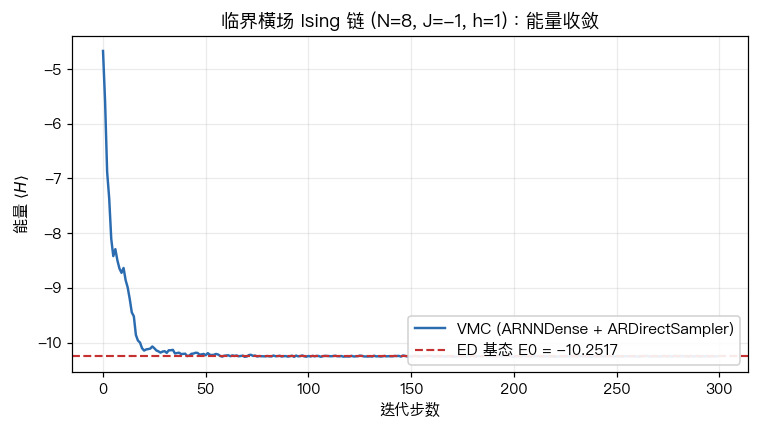

In [9]:
import matplotlib.pyplot as plt

# matplotlib 默认字体无中文字形，macOS 上指定可用中文字体
plt.rcParams["font.sans-serif"] = ["PingFang HK", "Hiragino Sans GB", "Heiti TC", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
ax.plot(iters, E_hist, lw=1.6, color="#2b6cb0", label="VMC (ARNNDense + ARDirectSampler)")
ax.axhline(E0, color="#c53030", ls="--", lw=1.4, label=f"ED 基态 E0 = {E0:.4f}")
ax.set_xlabel("迭代步数")
ax.set_ylabel(r"能量 $\langle H\rangle$")
ax.set_title("临界横场 Ising 链 (N=8, J=-1, h=1)：能量收敛")
ax.legend(loc="lower right", framealpha=0.9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 5 · 核心对比：`ARDirectSampler` vs `MetropolisSampler`

这是本课最重要的概念。训练分布（03 课）和自回归 VMC（04 课）里我们早已埋下伏笔，现在在 NetKet 里对号入座：

### 两种采样器的工作方式

**`MetropolisSampler`（默认）——"建议 + 拒绝"的马尔可夫链**

1. 从某个初态出发（或随机态）；
2. 提议翻转一个自旋：$x \to x'$；
3. 以接受率 $\min\!\big(1,\ \lvert\psi(x')\rvert^2/\lvert\psi(x)\rvert^2\big)$ 决定是否接受。

它**不需要知道** $|\psi|^2$ 的归一化常数 $Z$，对任何模型都适用。代价是：

- 需要 **burn-in**：链条要走一段才"忘记"初始位置，收敛到目标分布；
- 样本之间**自相关**（连续两步常常是同一个构型或高度相似），有效样本数远小于名义样本数，必须用 $\tau_{\text{corr}}$ 诊断、用 sweep/thinning 稀释；
- 在波函数极陡的区域接受率失衡时，链条会"卡住"。

**`ARDirectSampler`（自回归专属）——精确按 $|\psi|^2$ 采样**

自回归结构给了我们完整的一组条件概率：

$$p(x) = |\psi(x)|^2 = P(x_1)\,P(x_2\mid x_1)\cdots P(x_N \mid x_{<N})$$

于是可以**从左到右逐位生成**：每一位用模型算出的条件概率直接抽取，无提议、无拒绝。这带来质变：

- **零 burn-in**：每个样本都是直接从目标分布抽出的；
- **零自相关**：样本之间严格独立，512 个样本就是 512 个有效样本，误差条 $\propto 1/\sqrt{N_{\text{samples}}}$ 实打实成立；
- 代价一：模型必须是自回归的，且要暴露 `conditional` 方法（NetKet 的 ARNN 系列都实现了）；
- 代价二：逐位生成是串行的（本课 $N=8$ 还好；`FastARNN` 系列用缓存把 $O(N^2)$ 降到 $O(N)$，但本环境 JIT 不支持，故未采用）。

### 亲手验证两件事

下面用**同一个训练好的模型**做两个小实验：

1. 直接调用 `model.conditional`，看前缀给定时逐位条件概率长什么样（这就是采样器逐位生成时用的量）；
2. 对比两种采样器输出的"相邻样本重复率"。**读数姿势要小心**：训练后的 $|\psi|^2$ 高度集中在少数 Néel 型构型上，即使是**独立**样本也会随机碰撞到同一构型；所以要对比的是两者的**差**——多出来的部分才是马尔可夫链"原地停留"的真实自相关。

In [10]:
# 实验 1：逐位条件概率（ARDirectSampler 每一步内部做的事）
# 构造前缀 x_0..x_3 = (1, 1, -1, -1)，问模型：第 5 个自旋取 +1 的概率是多少？
prefix = np.array([[1, 1, -1, -1, -1, -1, -1, -1]])
i = 4  # 0-based：询问第 5 位
p = model.apply(vstate.variables, prefix, i, method=model.conditional)
print(f"前 4 位 = {prefix[0, :4].tolist()} 时：")
print(f"  P(x_5 = +1 | x_0..x_3) = {float(p[0, 1]):.4f}")
print(f"  P(x_5 = -1 | x_0..x_3) = {float(p[0, 0]):.4f}   （两者之和 = {float(p[0].sum()):.1f}）")

前 4 位 = [1, 1, -1, -1] 时：


  P(x_5 = +1 | x_0..x_3) = 0.6596
  P(x_5 = -1 | x_0..x_3) = 0.3404   （两者之和 = 1.0）


In [11]:
# 实验 2：同一个训练好的模型，换上 MetropolisSampler 采样
sampler_metr = nk.sampler.MetropolisLocal(hi, n_chains=16, sweep_size=N)
vstate_metr = nk.vqs.MCState(sampler_metr, model, n_samples=512, seed=2)
vstate_metr.variables = vstate.variables  # 沿用训练好的参数

def duplicate_fraction(samples):
    # 相邻样本完全相同的比例（自相关的直观体现）
    s = np.asarray(samples).reshape(-1, N)
    return float(np.mean(np.all(s[1:] == s[:-1], axis=-1)))

d_ar = duplicate_fraction(vstate.samples)
d_me = duplicate_fraction(vstate_metr.samples)
print(f"{'采样器':<22s}{'输出形状':<16s}{'相邻重复率':>10s}")
print("-" * 50)
print(f"{'ARDirectSampler':<22s}{str(vstate.samples.shape):<16s}{d_ar:>10.4f}")
print(f"{'MetropolisLocal':<22s}{str(vstate_metr.samples.shape):<16s}{d_me:>10.4f}")
print()
print(f"读数：ARDirect 的 {d_ar:.3f} 并非自相关——训练后的 |ψ|² 高度集中在少数 Néel 型")
print(f"构型上，独立抽样也会随机碰撞。Metropolis 比它多出 {d_me - d_ar:+.3f}，那才是")
print(f"马尔可夫链'提议被拒绝、原地停留'造成的真实自相关。")
print()
E_ar = vstate.expect(H)
E_me = vstate_metr.expect(H)
print(f"能量交叉验证（同一模型）：ARDirect = {float(np.real(E_ar.mean)):.4f} ± {float(E_ar.error_of_mean):.4f}"
      f"  |  Metropolis = {float(np.real(E_me.mean)):.4f} ± {float(E_me.error_of_mean):.4f}")
print("两者都无偏地估计同一个 |ψ|² —— 采样器只影响效率与误差条，不影响期望。")

采样器                   输出形状                 相邻重复率
--------------------------------------------------
ARDirectSampler       (1, 512, 8)         0.1213
MetropolisLocal       (16, 32, 8)         0.2994

读数：ARDirect 的 0.121 并非自相关——训练后的 |ψ|² 高度集中在少数 Néel 型
构型上，独立抽样也会随机碰撞。Metropolis 比它多出 +0.178，那才是
马尔可夫链'提议被拒绝、原地停留'造成的真实自相关。

能量交叉验证（同一模型）：ARDirect = -10.2531 ± 0.0043  |  Metropolis = -10.2510 ± 0.0041
两者都无偏地估计同一个 |ψ|² —— 采样器只影响效率与误差条，不影响期望。


## 6 · 本课小结

- **侦察先行**：`dir()` + `inspect.signature` + docstring，10 秒避免一次"教程 API 不存在"的事故；
- **本课可用的组合**：`nk.models.ARNNDense` + `nk.sampler.ARDirectSampler` + `QGTJacobianDense(holomorphic=False)` + `solver.svd` 的 SR，300 步把临界 TFIM（N=8）的相对误差压到 **0.1% 量级**；
- **采样器的本质区别**：Metropolis 是"建议 + 拒绝"的马尔可夫链（burn-in + 自相关），ARDirect 是利用自回归分解**精确逐位生成** $|\psi|^2$ 的独立样本——不用 burn-in，误差条是真误差条；
- **通用性 vs 效率的取舍**：任何模型都能配 Metropolis；只有（Fast）ARNN 这类自回归模型能配 ARDirect，换来的是采样质量与诊断的简化。

### 本环境实测踩坑记录（如实记录，供复现）

| 坑 | 现象 | 解法 |
|---|---|---|
| `nk.models.MADE` 不存在 | `AttributeError` | 3.21 用 `ARNNDense` / `ARNNConv1D` 等替代 |
| 默认 SR 配置 | 与 jax 0.9.2 冲突报错 | 指定 `QGTJacobianDense(holomorphic=False)` + `svd` + `diag_shift=0.01` |
| `FastARNNDense` 等 | JIT 下 `Slice entries must be static integers` | 本课不用；其 docstring 亦自述 JIT 未支持 |
| 采样数 < 参数数时用 SR | `InsufficientSamplesForSRWarning` | SVD + `diag_shift` 正则可稳定求解（本课实测收敛 0.01%）；新式做法改用 `nk.driver.VMC_SR` |
| `full_ed(hi, H)` 写法 | `TypeError` | 本版本签名是 `full_ed(operator)` |
| `jax.PRNGKey` | 已被移除 | 用 `nk.jax.PRNGKey` |

**下一步**：打开 `可视化-自回归采样演示.html`，动眼动手看掩码因果结构与逐位采样动画，把 02 课的 MADE 掩码和本课的 ARDirectSampler 在脑中串成一条线。